# Experiment 8 — Random Forest

**Dataset:** Fruits Dataset (Images) (Kaggle)

**Objective:** Classify fruit images using a Random Forest and demonstrate how majority voting across individual trees produces the final class.

> Kaggle setup: Add the dataset listed above to the notebook. The code automatically searches `/kaggle/input` for the required files/folders where possible.

In [1]:

import os, glob, warnings
warnings.filterwarnings("ignore")


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

## 1. Load a Kaggle fruit image dataset

In [3]:
# Search for directories that contain fruit images.
image_exts = {".jpg",".jpeg",".png",".bmp",".webp"}
records = []

for root, dirs, files in os.walk("/kaggle/input"):
    image_files = [f for f in files if os.path.splitext(f)[1].lower() in image_exts]
    if image_files:
        label = os.path.basename(root)
        # Keep folders with plausible class names and enough images.
        for f in image_files:
            records.append((os.path.join(root,f), label))

if not records:
    raise FileNotFoundError("Add a Kaggle fruit image dataset, e.g. 'Fruits Dataset (Images)'.")

data = pd.DataFrame(records, columns=["path","label"])
print(data["label"].value_counts().head(20))
display(data.head())

label
apple fruit         40
orange fruit        40
strawberry fruit    40
grapes fruit        40
banana fruit        40
cherry fruit        40
kiwi fruit          40
chickoo fruit       40
mango fruit         39
Name: count, dtype: int64


,path,label
0,/kaggle/input/datasets/shreyapmaher/fruits-dat...,apple fruit
1,/kaggle/input/datasets/shreyapmaher/fruits-dat...,apple fruit
2,/kaggle/input/datasets/shreyapmaher/fruits-dat...,apple fruit
3,/kaggle/input/datasets/shreyapmaher/fruits-dat...,apple fruit
4,/kaggle/input/datasets/shreyapmaher/fruits-dat...,apple fruit


## 2. Extract compact HOG image features

In [4]:
# Use a manageable subset if a large fruit dataset is attached.
MAX_PER_CLASS = 60
data = data.groupby("label", group_keys=False).head(MAX_PER_CLASS).reset_index(drop=True)

def extract_hog(path):
    image = Image.open(path).convert("L").resize((64,64))
    arr = np.asarray(image, dtype=np.float32) / 255.0
    feat = hog(arr, orientations=9, pixels_per_cell=(8,8),
               cells_per_block=(2,2), block_norm="L2-Hys")
    return feat

features = []
labels = []
valid_paths = []

for p, lab in zip(data["path"], data["label"]):
    try:
        features.append(extract_hog(p))
        labels.append(lab)
        valid_paths.append(p)
    except Exception:
        pass

X = np.array(features)
y = np.array(labels)

print("Feature matrix:", X.shape)
print("Classes:", np.unique(y))

Feature matrix: (359, 1764)
Classes: ['apple fruit' 'banana fruit' 'cherry fruit' 'chickoo fruit'
 'grapes fruit' 'kiwi fruit' 'mango fruit' 'orange fruit'
 'strawberry fruit']


## 3. Train Random Forest

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight="balanced"
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test,y_pred)*100,2), "%")
print(classification_report(y_test,y_pred))

Accuracy: 48.61 %
                  precision    recall  f1-score   support

     apple fruit       0.71      0.62      0.67         8
    banana fruit       0.67      0.50      0.57         8
    cherry fruit       0.38      0.38      0.38         8
   chickoo fruit       0.67      0.50      0.57         8
    grapes fruit       0.70      0.88      0.78         8
      kiwi fruit       0.36      0.62      0.45         8
     mango fruit       0.00      0.00      0.00         8
    orange fruit       0.33      0.25      0.29         8
strawberry fruit       0.50      0.62      0.56         8

        accuracy                           0.49        72
       macro avg       0.48      0.49      0.47        72
    weighted avg       0.48      0.49      0.47        72



## 4. Confusion matrix

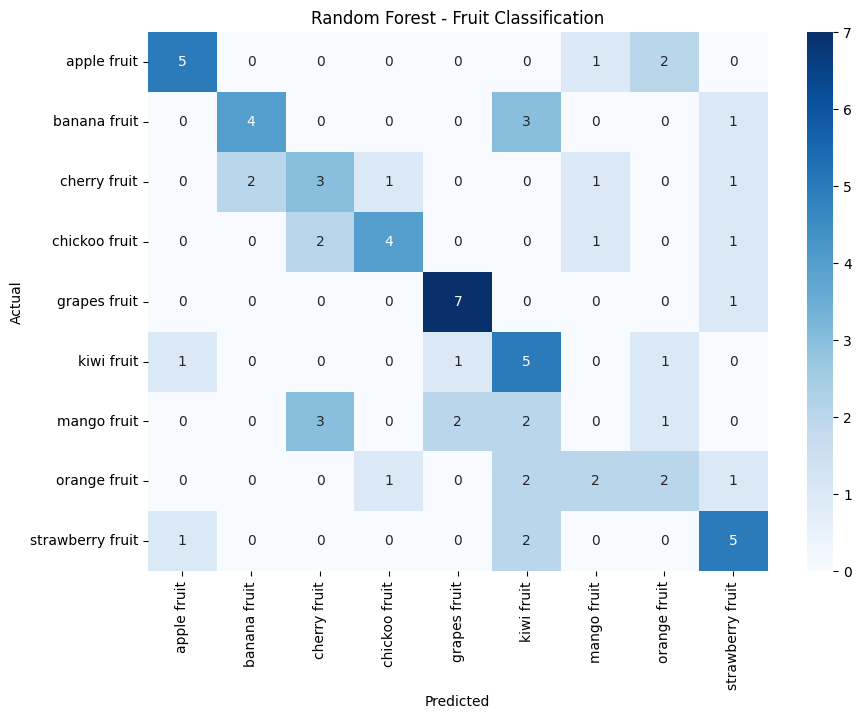

In [6]:
labels_sorted = sorted(np.unique(y))
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Fruit Classification")
plt.show()

## 5. Demonstrate the Random Forest majority-voting idea

In [7]:
# For one test sample, show how individual trees vote.
sample = X_test[0].reshape(1,-1)
tree_votes = [tree.predict(sample)[0] for tree in model.estimators_]

vote_counts = pd.Series(tree_votes).value_counts()
print("Individual tree votes:")
display(vote_counts.to_frame("votes"))
print("Final Random Forest prediction:", model.predict(sample)[0])

Individual tree votes:


,votes
0.0,41
8.0,23
4.0,17
7.0,17
6.0,15
5.0,12
2.0,12
3.0,9
1.0,4


Final Random Forest prediction: apple fruit
